# ASC1/2 Locus Coverage Plots

### imports

In [2]:
library(Gviz)
library(rtracklayer)
library(GenomicRanges)
library(SummarizedExperiment)
library(biomaRt)
library(TxDb.Hsapiens.UCSC.hg38.knownGene)
library(org.Hs.eg.db)
library(dplyr)

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, intersect, is.unsorted,
    lapply, mapply, match, mget, order, paste, pmax, pmax.int, pmin,
    pmin.int, rank, rbind, rownames, sapply, saveRDS, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:



In [3]:
devtools::load_all('/home/workspace/MOCHA')
devtools::load_all('/home/workspace/ChAI')

ℹ Loading MOCHA
in method for 'callOpenTiles' with signature 'ATACFragments="ArchRProject"': no definition for class "ArchRProject"

ℹ Loading ChAI


### gene locus settings

need to change these based on which region of the gene you want look at (I check in IGviewer beforehand)

In [4]:
bw_asc5  <- "/home/workspace/Meta_Files/ASC5__All_Coverage.bw"
bw_asc2  <- "/home/workspace/Meta_Files/ASC2__All_Coverage.bw"

### create motif annotation files

In [5]:
STM <- readRDS('/home/workspace/Run_Metatype_12v5/MOCHA_SampleTileMatrix_Meta.rds')

In [6]:
library(chromVARmotifs)
data(human_pwms_v2)

In [7]:
# motif set should already be added to STM
motifsGRanges <- metadata(STM)$Motifs

In [8]:
gene_symbols <- c("BATF", "IRF8", "CD69", "CD86", "ITGB7", "SEMA4D")
# really only care about BATF and CD69 now

In [9]:
# Map gene symbols → Entrez IDs
entrez <- mapIds(
  org.Hs.eg.db,
  keys = gene_symbols,
  keytype = "SYMBOL",
  column = "ENTREZID",
  multiVals = "first")

txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene

# Extract gene ranges
gr_genes <- genes(txdb)[entrez]
print(length(gr_genes))

gr_genes$gene_id     <- names(gr_genes)        # Entrez ID from TxDb
gr_genes$gene_symbol <- names(entrez)

promoters_gr <- promoters(
  gr_genes,
  upstream = 3000,
  downstream = 2000
)

target_regions <- c(gr_genes, promoters_gr)

target_regions

'select()' returned 1:1 mapping between keys and columns

  2162 genes were dropped because they have exons located on both strands
  of the same reference sequence or on more than one reference sequence,
  so cannot be represented by a single genomic range.
  Use 'single.strand.genes.only=FALSE' to get all the genes in a
  GRangesList object, or use suppressMessages() to suppress this message.



[1] 6


GRanges object with 12 ranges and 2 metadata columns:
        seqnames              ranges strand |     gene_id gene_symbol
           <Rle>           <IRanges>  <Rle> | <character> <character>
  10538    chr14   75522455-75546993      + |       10538        BATF
   3394    chr16   85899116-85922606      + |        3394        IRF8
    969    chr12     9752486-9760901      - |         969        CD69
    942     chr3 122055362-122121139      + |         942        CD86
   3695    chr12   53191323-53207282      - |        3695       ITGB7
    ...      ...                 ...    ... .         ...         ...
   3394    chr16   85896116-85901115      + |        3394        IRF8
    969    chr12     9758902-9763901      - |         969        CD69
    942     chr3 122052362-122057361      + |         942        CD86
   3695    chr12   53205283-53210282      - |        3695       ITGB7
  10507     chr9   89496131-89501130      - |       10507      SEMA4D
  -------
  seqinfo: 711 sequences (

In [10]:
hits <- queryHits(findOverlaps(rowRanges(STM), target_regions))

In [11]:
se_filtered <- STM[hits, ]
se_filtered

class: RangedSummarizedExperiment 
dim: 221 6 
metadata(8): summarizedData Genome ... InsertionBias Motifs
assays(2): ASC1_2 ASC5_2
rownames(221): chr12:53197000-53197499 chr12:53197500-53197999 ...
  chr9:89499000-89499499 chr9:89499500-89499999
rowData names(2): ASC1_2 ASC5_2
colnames(6): EXP-00776-P1_BMC05967-001 EXP-00776-P1_SP05965-01 ...
  EXP-00776-P1_SP06133-01 EXP-00776-P1_SP06134-01
colData names(5): Sample pool_id chip_id batch_id PassQC

In [12]:
se_filtered <- subsetMOCHAObject(se_filtered, subsetBy='celltype', groupList=c('ASC1_2'))
rowData(se_filtered) <- rowData(se_filtered)[, c('ASC1_2'), drop = FALSE]

In [13]:
motifsGRanges <- metadata(se_filtered)$Motifs

In [14]:
se_filtered

class: RangedSummarizedExperiment 
dim: 219 6 
metadata(8): summarizedData Genome ... InsertionBias Motifs
assays(1): ASC1_2
rownames(219): chr12:53197000-53197499 chr12:53197500-53197999 ...
  chr9:89499000-89499499 chr9:89499500-89499999
rowData names(1): ASC1_2
colnames(6): EXP-00776-P1_BMC05967-001 EXP-00776-P1_SP05965-01 ...
  EXP-00776-P1_SP06133-01 EXP-00776-P1_SP06134-01
colData names(5): Sample pool_id chip_id batch_id PassQC

In [15]:
exportPath <- exportMotifs(
  SampleTileObject=se_filtered,
  motifsGRanges,
  motifSetName = "Motifs",
  filterByOpenTiles = TRUE,
  outDir='/home/workspace/Meta_Files/Motif_Bed',
  verbose = TRUE
)


Attaching package: 'Biostrings'


The following object is masked from 'package:grid':

    pattern


The following object is masked from 'package:base':

    strsplit



Attaching package: 'BiocIO'


The following object is masked from 'package:rtracklayer':

    FileForFormat


Exporting: /home/workspace/Meta_Files/Motif_Bed/ASC1_2__Motifs__motifset.bigBed



In [16]:
bed <- import(unlist(exportPath))

In [17]:
bed

GRanges object with 13549 ranges and 2 metadata columns:
          seqnames            ranges strand |     score      strand
             <Rle>         <IRanges>  <Rle> | <numeric> <character>
      [1]    chr12   9752026-9752038      * |         8           +
      [2]    chr12   9752027-9752038      * |         8           -
      [3]    chr12   9752028-9752037      * |         8           -
      [4]    chr12   9752028-9752040      * |         9           +
      [5]    chr12   9752029-9752039      * |         7           +
      ...      ...               ...    ... .       ...         ...
  [13545]     chr9 89499927-89499940      * |         8           -
  [13546]     chr9 89499927-89499940      * |         8           -
  [13547]     chr9 89499933-89499941      * |         8           -
  [13548]     chr9 89499943-89499956      * |         8           -
  [13549]     chr9 89499943-89499956      * |         7           -
  -------
  seqinfo: 5 sequences from an unspecified genome

In [18]:
# need to map motif names back to these regions
motif_grl <- motifsGRanges

motif_df <- bind_rows(
  lapply(names(motif_grl), function(tf) {
    df <- as.data.frame(motif_grl[[tf]])
    df$motif_name <- tf
    df
  })
)

motif_gr <- GRanges(
  seqnames = motif_df$seqnames,
  ranges = IRanges(start = motif_df$start, end = motif_df$end),
  strand = motif_df$strand,
  motif_name = motif_df$motif_name,
  score = motif_df$score
)

In [19]:
motif_filtered_gr <- subsetByOverlaps(motif_gr, bed)
motif_filtered_gr

GRanges object with 13562 ranges and 2 metadata columns:
          seqnames            ranges strand |  motif_name     score
             <Rle>         <IRanges>  <Rle> | <character> <numeric>
      [1]    chr12   9763456-9763467      + |      TFAP2B   8.95950
      [2]    chr14 75539617-75539628      + |      TFAP2B   8.94510
      [3]    chr14 75539617-75539628      - |      TFAP2B   8.71342
      [4]    chr14 75542980-75542991      - |      TFAP2B   8.47313
      [5]     chr9 89372703-89372714      + |      TFAP2B   9.13196
      ...      ...               ...    ... .         ...       ...
  [13558]     chr9 89401005-89401023      - |       TBX22   4.24885
  [13559]     chr9 89410409-89410427      + |       TBX22   1.94139
  [13560]     chr9 89410409-89410427      - |       TBX22   3.69347
  [13561]     chr9 89435319-89435337      - |       TBX22   2.98733
  [13562]     chr9 89437423-89437441      + |       TBX22   2.18370
  -------
  seqinfo: 24 sequences from an unspecified genom

now that we have all the motifs that are present surrounding our genes of interest, let's filter by motfis that are significantly upregulated (more open) in ASC2 based on our ChromVAR analysis

In [20]:
chromVAR_enriched <- read.csv('/home/workspace/Run_Metatype_threshold/anovaEnrichments.csv')

In [21]:
celltype_enriched <- chromVAR_enriched %>%
  filter(cell_type %in% c('ASC2', 'ASC1'))

In [22]:
dim(celltype_enriched)

[1] 1740   15

In [23]:
head(celltype_enriched, 1)

,X.1,X,contrast,estimate,SE,df,t.ratio,p.value,motif,p_adj,mlogadjpval,cell_type,statistic,is_top20,is_expressed
,<int>,<int>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<lgl>,<lgl>
1,1,1,ASC1 effect,-0.9107458,0.2688777,19,-3.387212,0.005154361,TFAP2B,0.009643644,2.015759,ASC1,-1.835844,FALSE,FALSE


In [24]:
# only want positive and significant motifs
celltype_enriched <- celltype_enriched %>%
  filter(estimate > 0, p_adj < 0.1)

In [25]:
# filter by expression detection 
celltype_enriched <- celltype_enriched %>%
  filter(is_expressed)
dim(celltype_enriched)

[1] 111  15

In [26]:
length(unique(celltype_enriched$motif))

[1] 90

In [27]:
motif_filtered_gr <- motif_filtered_gr[motif_filtered_gr$motif_name %in% unique(celltype_enriched$motif)]

In [28]:
motif_filtered_gr

GRanges object with 1778 ranges and 2 metadata columns:
         seqnames            ranges strand |  motif_name     score
            <Rle>         <IRanges>  <Rle> | <character> <numeric>
     [1]    chr12 53206533-53206546      + |      ARID5B   8.82610
     [2]    chr12 53207371-53207384      - |      ARID5B   9.05232
     [3]    chr12   9757828-9757841      + |      ARID5B   9.61724
     [4]    chr12   9761834-9761847      - |      ARID5B   9.28346
     [5]    chr16 85898118-85898131      + |      ARID5B  10.99414
     ...      ...               ...    ... .         ...       ...
  [1774]     chr9 89436166-89436175      - |       ASCL1   9.34682
  [1775]    chr12 53197772-53197786      + |       SMAD5  10.41385
  [1776]    chr16 85905535-85905549      - |       SMAD5   9.22682
  [1777]     chr9 89496853-89496867      + |       SMAD5   8.91556
  [1778]     chr9 89498094-89498108      - |       SMAD5   9.33258
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengt

ok so we have the motifs that are significantly and positively enriched for ASCs 1 and 2 at our genes of interest, now we can plot

### import big wigs

*** this is the only thing that needs to be changed for each run ***

In [91]:
target_region <- target_regions[target_regions$gene_symbol == "CD69"]
target_region

GRanges object with 2 ranges and 2 metadata columns:
      seqnames          ranges strand |     gene_id gene_symbol
         <Rle>       <IRanges>  <Rle> | <character> <character>
  969    chr12 9752486-9760901      - |         969        CD69
  969    chr12 9758902-9763901      - |         969        CD69
  -------
  seqinfo: 711 sequences (1 circular) from hg38 genome

In [92]:
# going to pad either side of the gene to catch any promoter or differential regions
# start(target_region) <- start(target_region) - 500
# end(target_region) <- end(target_region) + 500
# target_region

In [93]:
start <- min(start(target_region))
end <- max(end(target_region))
strand <- strand(target_region)[1]
chr <- as.character(seqnames(target_region)[1])

In [94]:
bw <- import(bw_asc5, as = "RleList")
asc5_rle <- bw[[chr]][start:end]  # base-level coverage

bw2 <- import(bw_asc2, as = "RleList")
asc2_rle <- bw2[[chr]][start:end]

In [95]:
asc5_vec <- as.numeric(asc5_rle)
asc2_vec <- as.numeric(asc2_rle)

In [96]:
delta_vec <- asc2_vec - asc5_vec

In [97]:
gr <- GRanges(
  seqnames = chr,
  ranges   = IRanges(start = start:end, width = 1),
  strand   = strand
)

# Sanity check: vector lengths must match region size
stopifnot(
  length(gr) == length(asc5_vec),
  length(asc2_vec) == length(asc5_vec),
  length(delta_vec) == length(asc5_vec)
)

# Attach scores
asc5_gr  <- gr; asc5_gr$score  <- asc5_vec
asc2_gr  <- gr; asc2_gr$score  <- asc2_vec
delta_gr <- gr; delta_gr$score <- delta_vec


### plot motif track

In [98]:
motif_filtered_gr

GRanges object with 1778 ranges and 2 metadata columns:
         seqnames            ranges strand |  motif_name     score
            <Rle>         <IRanges>  <Rle> | <character> <numeric>
     [1]    chr12 53206533-53206546      + |      ARID5B   8.82610
     [2]    chr12 53207371-53207384      - |      ARID5B   9.05232
     [3]    chr12   9757828-9757841      + |      ARID5B   9.61724
     [4]    chr12   9761834-9761847      - |      ARID5B   9.28346
     [5]    chr16 85898118-85898131      + |      ARID5B  10.99414
     ...      ...               ...    ... .         ...       ...
  [1774]     chr9 89436166-89436175      - |       ASCL1   9.34682
  [1775]    chr12 53197772-53197786      + |       SMAD5  10.41385
  [1776]    chr16 85905535-85905549      - |       SMAD5   9.22682
  [1777]     chr9 89496853-89496867      + |       SMAD5   8.91556
  [1778]     chr9 89498094-89498108      - |       SMAD5   9.33258
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengt

In [99]:
select_motifs <- subsetByOverlaps(
  motif_filtered_gr,
  target_region
)

In [100]:
select_motifs

GRanges object with 31 ranges and 2 metadata columns:
       seqnames          ranges strand |  motif_name     score
          <Rle>       <IRanges>  <Rle> | <character> <numeric>
   [1]    chr12 9761834-9761847      - |      ARID5B   9.28346
   [2]    chr12 9757791-9757812      - |        REST   6.40939
   [3]    chr12 9758734-9758748      - |      BCL11A   9.20479
   [4]    chr12 9760584-9760598      - |      BCL11A   9.15893
   [5]    chr12 9758921-9758930      - |        OSR2   8.29443
   ...      ...             ...    ... .         ...       ...
  [27]    chr12 9761039-9761044      - |       RUNX1   7.50643
  [28]    chr12 9761526-9761531      - |       RUNX1   7.50643
  [29]    chr12 9761750-9761755      - |       RUNX1   7.50643
  [30]    chr12 9758734-9758748      - |      BCL11B   9.20479
  [31]    chr12 9760584-9760598      - |      BCL11B   9.15893
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

also need to highlight differentially accessible region and filter to motifs to only in that region

In [101]:
dat_table <- read.csv('/home/workspace/Run_Metatype_12v5/DAT_table_5v12_annotated.csv')

In [102]:
# also read in 1 vs all comparison dats
dat_table2 <- read.csv('/home/workspace/Run_Metatype_threshold/DAT_table_gene_annotated.csv')

In [103]:
length(unique(dat_table$Tiles))

[1] 66614

In [104]:
length(unique(dat_table2$Tiles))

[1] 80329

doesn't really matter if we filter dat table since we hand selected our target genes/promoter regions based on this table anyway

In [105]:
dats <- unique(c(dat_table$Tiles, dat_table2$Tiles))

In [106]:
dats <- StringsToGRanges(dats)

In [107]:
dats

GRanges object with 111804 ranges and 0 metadata columns:
           seqnames              ranges strand
              <Rle>           <IRanges>  <Rle>
       [1]    chr10 100009000-100009499      *
       [2]    chr10 100010000-100010499      *
       [3]    chr10 100014000-100014499      *
       [4]    chr10 100014500-100014999      *
       [5]    chr10 100020500-100020999      *
       ...      ...                 ...    ...
  [111800]     chrY     7336500-7336999      *
  [111801]     chrY     7340000-7340499      *
  [111802]     chrY     8437500-8437999      *
  [111803]     chrX   73851500-73851999      *
  [111804]    chr18   10252500-10252999      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [108]:
select_dats <- subsetByOverlaps(
  dats,
  target_region
)

In [109]:
select_dats

GRanges object with 7 ranges and 0 metadata columns:
      seqnames          ranges strand
         <Rle>       <IRanges>  <Rle>
  [1]    chr12 9752000-9752499      *
  [2]    chr12 9758500-9758999      *
  [3]    chr12 9759000-9759499      *
  [4]    chr12 9761500-9761999      *
  [5]    chr12 9760500-9760999      *
  [6]    chr12 9761000-9761499      *
  [7]    chr12 9758000-9758499      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [110]:
str_select_dats <- GRangesToString(select_dats)

In [111]:
str_select_dats

[1] "chr12:9752000-9752499" "chr12:9758500-9758999" "chr12:9759000-9759499"
[4] "chr12:9761500-9761999" "chr12:9760500-9760999" "chr12:9761000-9761499"
[7] "chr12:9758000-9758499"

In [112]:
dat_table2 %>% filter(Tiles %in% str_select_dats)

X,gene_id,promoter_gene_id,promoter_symbol,gene_symbol,annotation,Estimate,Std_Error,z_value,p_value,FDR,Tiles,CellType
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
chr12:9759000-9759499,969,NA,,CD69,intron,1.719230,0.6344304,2.709879,0.0067307733,0.016707119,chr12:9759000-9759499,ASC1
chr12:9760500-9760999,969,969,CD69,CD69,intron,2.253927,0.7118362,3.166357,0.0015436130,0.004959587,chr12:9760500-9760999,ASC1
chr12:9761000-9761499,NA,969,CD69,,promoter,2.307232,0.7885944,2.925753,0.0034362413,0.009594616,chr12:9761000-9761499,ASC1
chr12:9758000-9758499,969,NA,,CD69,intron,1.434249,0.4907687,2.922454,0.0034728453,0.022138437,chr12:9758000-9758499,ASC2
chr12:9758500-9758999,969,NA,,CD69,intron,1.145402,0.3685988,3.107450,0.0018870865,0.014066389,chr12:9758500-9758999,ASC2
chr12:9759000-97594991,406926,406926,MIR135A2,MIR135A2,intron,1.042304,0.4053659,2.571267,0.0101327243,0.048180133,chr12:9759000-9759499,ASC2
chr12:9760500-97609991,406926,406926,MIR135A2,MIR135A2,intron,1.799755,0.5277278,3.410384,0.0006487141,0.006342416,chr12:9760500-9760999,ASC2
chr12:9761000-97614991,406926,406926,MIR135A2,MIR135A2,intron,1.415119,0.5028014,2.814469,0.0048857947,0.028423360,chr12:9761000-9761499,ASC2
chr12:9761500-9761999,NA,969,CD69,,promoter,1.336094,0.5800040,2.303594,0.0212454442,0.081526005,chr12:9761500-9761999,ASC2


In [113]:
select_dats

GRanges object with 7 ranges and 0 metadata columns:
      seqnames          ranges strand
         <Rle>       <IRanges>  <Rle>
  [1]    chr12 9752000-9752499      *
  [2]    chr12 9758500-9758999      *
  [3]    chr12 9759000-9759499      *
  [4]    chr12 9761500-9761999      *
  [5]    chr12 9760500-9760999      *
  [6]    chr12 9761000-9761499      *
  [7]    chr12 9758000-9758499      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

subset motifs again 

In [114]:
select_motifs <- subsetByOverlaps(
  select_motifs,
  select_dats
)

In [115]:
select_dats <- reduce(select_dats)
select_dats

GRanges object with 3 ranges and 0 metadata columns:
      seqnames          ranges strand
         <Rle>       <IRanges>  <Rle>
  [1]    chr12 9752000-9752499      *
  [2]    chr12 9758000-9759499      *
  [3]    chr12 9760500-9761999      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [116]:
select_motifs

GRanges object with 26 ranges and 2 metadata columns:
       seqnames          ranges strand |  motif_name     score
          <Rle>       <IRanges>  <Rle> | <character> <numeric>
   [1]    chr12 9761834-9761847      - |      ARID5B   9.28346
   [2]    chr12 9758734-9758748      - |      BCL11A   9.20479
   [3]    chr12 9760584-9760598      - |      BCL11A   9.15893
   [4]    chr12 9758921-9758930      - |        OSR2   8.29443
   [5]    chr12 9759003-9759011      - |       ZBTB3   7.07076
   ...      ...             ...    ... .         ...       ...
  [22]    chr12 9761039-9761044      - |       RUNX1   7.50643
  [23]    chr12 9761526-9761531      - |       RUNX1   7.50643
  [24]    chr12 9761750-9761755      - |       RUNX1   7.50643
  [25]    chr12 9758734-9758748      - |      BCL11B   9.20479
  [26]    chr12 9760584-9760598      - |      BCL11B   9.15893
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [117]:
top20 <- celltype_enriched %>%
  filter(p_adj < 0.1) %>%
  filter(estimate > 0) %>%
  group_by(cell_type) %>%
  slice_max(order_by = estimate, n = 20, with_ties = FALSE) %>%
  ungroup()

In [118]:
select_motifs_20 <- select_motifs[select_motifs$motif_name %in% top20$motif, ]
length(unique(select_motifs_20$motif_name))

[1] 5

In [119]:
select_motifs_20

GRanges object with 9 ranges and 2 metadata columns:
      seqnames          ranges strand |  motif_name     score
         <Rle>       <IRanges>  <Rle> | <character> <numeric>
  [1]    chr12 9758734-9758748      - |      BCL11A   9.20479
  [2]    chr12 9760584-9760598      - |      BCL11A   9.15893
  [3]    chr12 9758729-9758749      - |        IRF1   7.19232
  [4]    chr12 9759270-9759290      - |        IRF1   8.21762
  [5]    chr12 9758728-9758745      - |        IRF2   5.66188
  [6]    chr12 9761033-9761047      - |       RUNX2   8.37120
  [7]    chr12 9761039-9761044      - |       RUNX1   7.50643
  [8]    chr12 9761526-9761531      - |       RUNX1   7.50643
  [9]    chr12 9761750-9761755      - |       RUNX1   7.50643
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

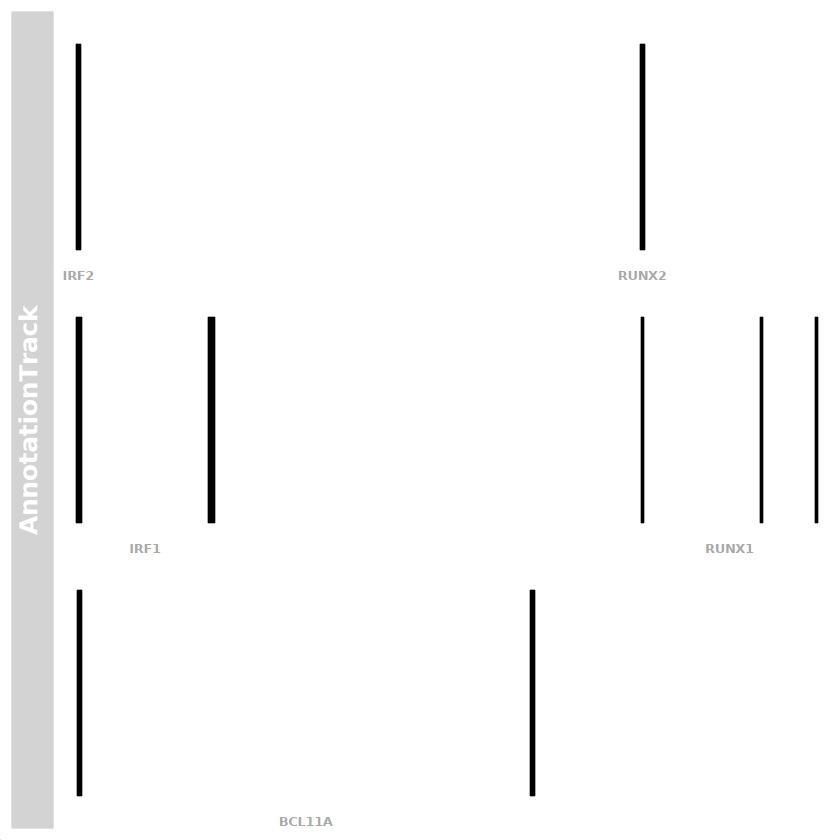

In [121]:
motif_track <- AnnotationTrack(
    select_motifs_20,
    shape='box',
    group = mcols(select_motifs_20)$motif_name,
    # featureAnnotation='group',
    groupAnnotation='group',
    fontcolor.group = "darkgrey",
    fontcolor.feature = "darkgrey",
    just.group = 'below',
    just.feature = 'above',
    stacking = "squish",
    # cex.feature = 0.8,
    col.line = NA,
    fill = 'black',
    col = 'black'
)

plotTracks(motif_track)

## Coverage Tracks

In [122]:
ylim_all <- range(c(asc5_vec, asc2_vec, asc5_vec - asc2_vec), na.rm=TRUE)

asc5_track <- DataTrack(
    range = asc5_gr,
    type = "histogram",
    name = "ASC5",
    col.histogram = "#E8A29E",
    fill = "#E8A29E",
    ylim = ylim_all
)

asc2_track <- DataTrack(
    range = asc2_gr,
    type = "histogram",
    name = "ASC2",
    col.histogram = "#4B6A94",
    fill = "#4B6A94",
    ylim = ylim_all
)

delta_track <- DataTrack(
    range = delta_gr,
    type = "histogram",
    name = "Delta",
    col.histogram = "#696969",
    fill = "#696969",
    ylim = ylim_all
)

## Gene Track

In [123]:
gene_ids <- unique(target_region$gene_id) 
gene_symbol <- unique(target_region$gene_symbol) 

gene_track <- GeneRegionTrack(
    TxDb.Hsapiens.UCSC.hg38.knownGene,
    chromosome = chr,
    start = start,
    end = end,
    #  = as.character(strand),
    name = "",
    # symbol = gene_symbol,
    transcriptAnnotation = "symbol",
    collapseTranscripts = FALSE
)

# gene_track@range$symbol <- gene_symbol
# gene_track@range$transcript <- gene_symbol
# gene_track@range$symbol <- gene_symbols[as.character(gene_track@range$gene)]

# Customize appearance
displayPars(gene_track)$fill <- "darkgrey"
displayPars(gene_track)$col <- "darkgrey"
displayPars(gene_track)$lty <- 1
displayPars(gene_track)$arrowhead.width <- 0.1
displayPars(gene_track)$cex.group <- 0.8
displayPars(gene_track)$fontcolor.group <- "darkgrey"
displayPars(gene_track)$just.group <- "left"
displayPars(gene_track)$stacking <- "squish"

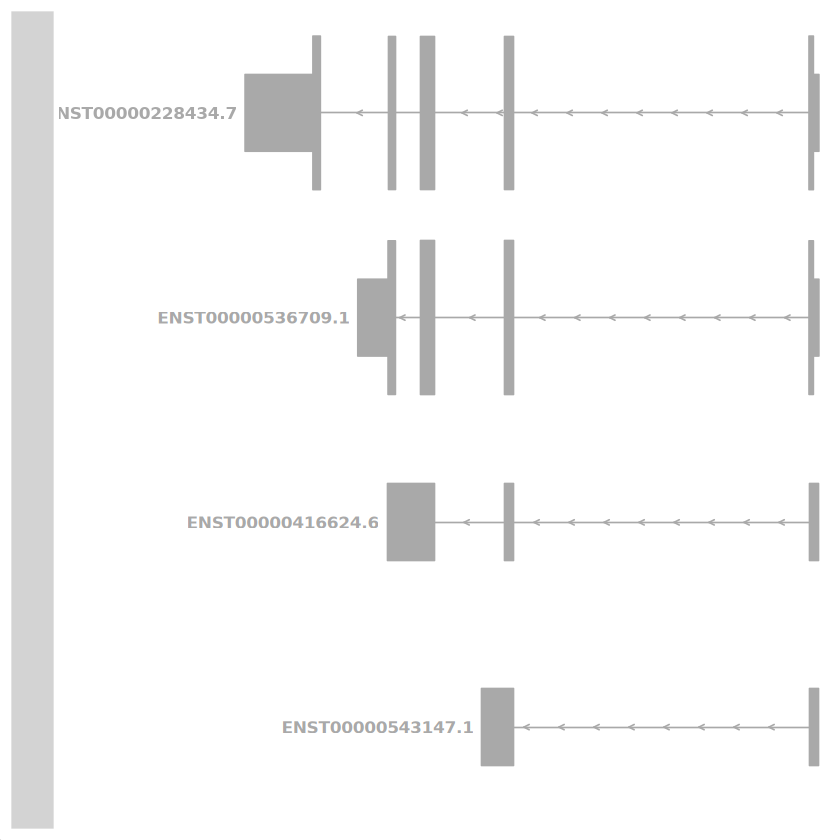

In [124]:
plotTracks(gene_track)

## Format Tracks

In [125]:
axis_track <- GenomeAxisTrack(
    labelPos = "below",
    littleTicks = TRUE,
    cex = 0.5,
    col="black",
    fontcolor="black",
    showID=FALSE
)

In [126]:
axis_track <- GenomeAxisTrack(
    labelPos = "below",
    col="black",
    fontcolor="black",
    showID=FALSE
)

In [127]:
spacer_track <- AnnotationTrack(
  start = start,
  end   = end,
  chromosome = chr,
  name = "",            # no title
  showTitle = FALSE,    # hide title
  showFeature = FALSE,  # hide any features
  showId = FALSE,
  fill = 'white',
  col = 'white',
)

## Plot Tracks

### BATF

In [315]:
select_dats

GRanges object with 6 ranges and 0 metadata columns:
      seqnames            ranges strand
         <Rle>         <IRanges>  <Rle>
  [1]    chr14 75520500-75523999      *
  [2]    chr14 75524500-75524999      *
  [3]    chr14 75526000-75526499      *
  [4]    chr14 75533000-75534499      *
  [5]    chr14 75539000-75539999      *
  [6]    chr14 75541500-75541999      *
  -------
  seqinfo: 24 sequences from an unspecified genome; no seqlengths

In [63]:
select_dats2 <- select_dats[1:2]

In [64]:
select_motifs2 <- subsetByOverlaps(
  select_motifs_20,
  select_dats2
)

In [87]:
motif_track <- AnnotationTrack(
    select_motifs2,
    shape='box',
    group = mcols(select_motifs2)$motif_name,
    # featureAnnotation='group',
    groupAnnotation='group',
    fontcolor.group = "darkgrey",
    just.group = 'left',
    cex.group = 0.8,
    col.line = NA,
    fill = 'black',
    col = 'black',
    extend.left = 5
)

In [88]:
# select_dats2 <- select_dats[2]
ht <- HighlightTrack(
  track = c(asc2_track, asc5_track, delta_track, motif_track),
  range = select_dats2,
  col = NA,
  fill = "#e8e8e8"
)

In [74]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000286639.8'))
gene_track@range$symbol <- 'BATF'

we're really only interested in the promoter region, let's zoom in

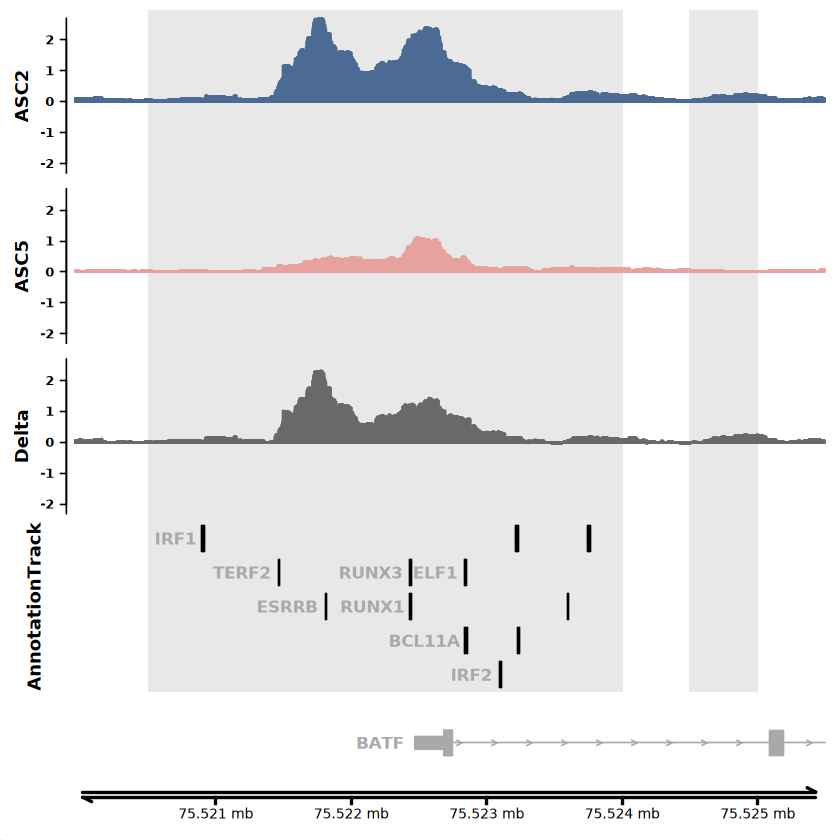

In [89]:
plotTracks(
    list(
        ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 500,
    to = end - 21500,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

In [90]:
pdf("coverage_plots_final/BATF_3.pdf")

plotTracks(
    list(
        ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 500,
    to = end - 21500,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

dev.off()

agg_record_1073753559 
                    2

### IRF8

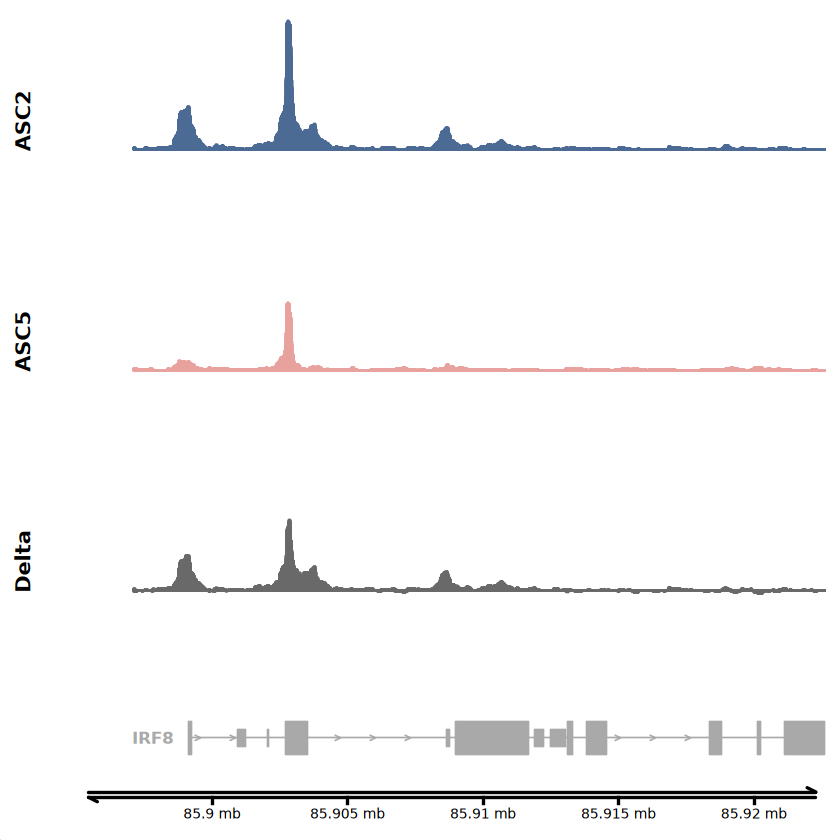

In [226]:
plotTracks(
    list(
        asc2_track,
        asc5_track,
        delta_track,
        # motif_track,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start - 2000,
    to = end,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

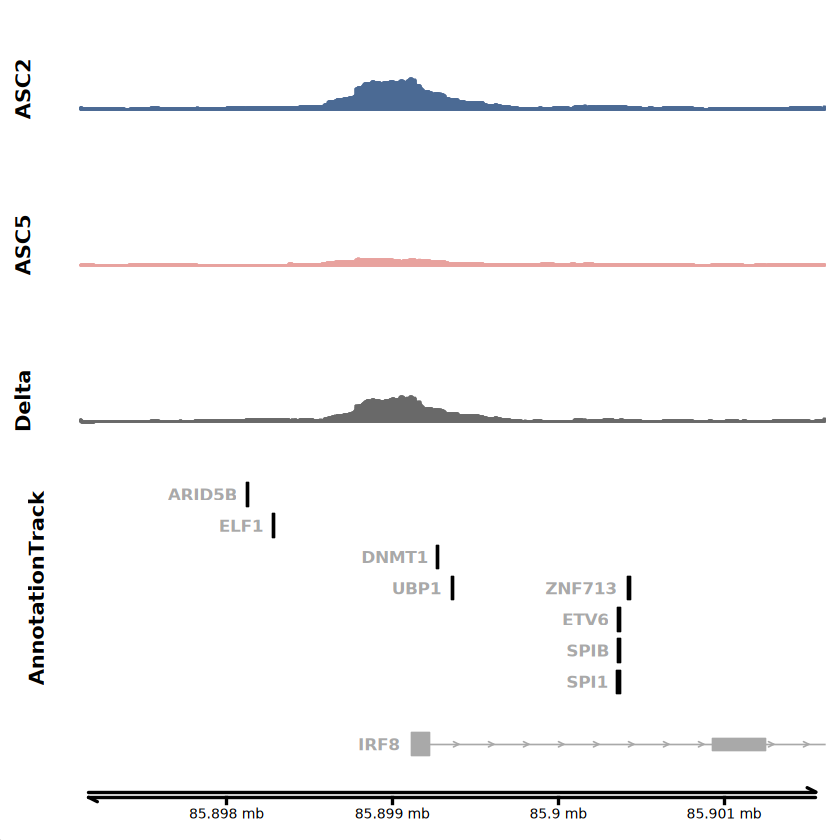

In [235]:
plotTracks(
    list(
        asc2_track,
        asc5_track,
        delta_track,
        motif_track,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start,
    to = end - 21000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

### CD69

In [128]:
displayPars(gene_track)$just.group <- "right"
displayPars(motif_track)$just.group <- "right"

In [129]:
ht <- HighlightTrack(
  track = c(asc2_track, asc5_track, delta_track, motif_track),
  range = select_dats,
  col = NA,
  fill = "#e8e8e8"
)

In [130]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000228434.7'))
gene_track@range$symbol <- 'CD69'

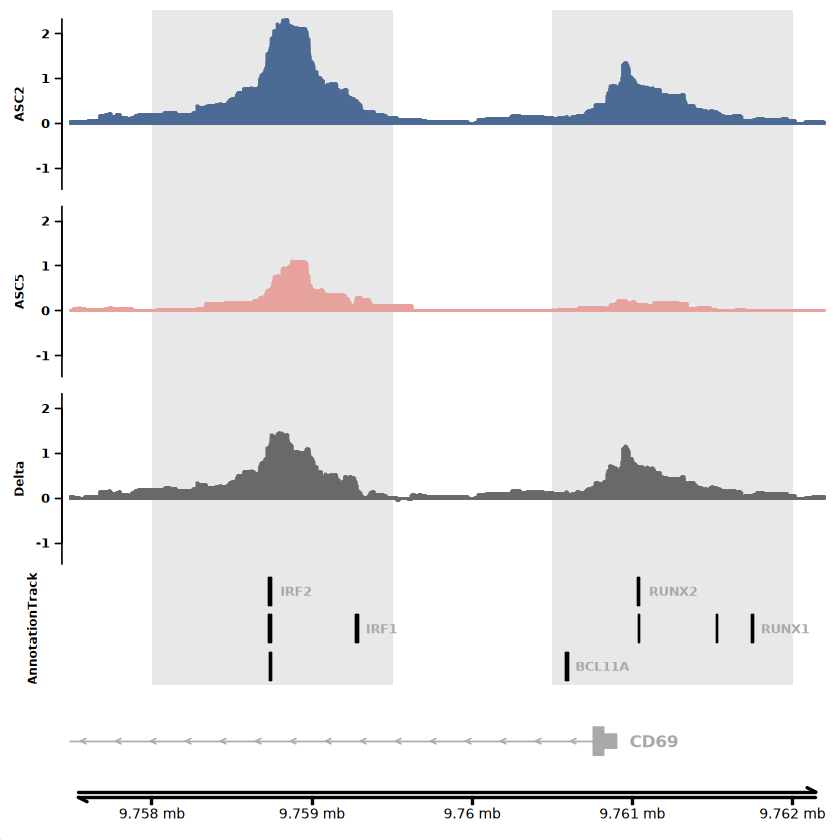

In [131]:
plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 5000,
    to = end - 1700,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

In [132]:
pdf("coverage_plots_final/CD69_2.pdf", width = 5, height = 6)

plotTracks(
    list(ht,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 5000,
    to = end - 1000,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white",
    col.axis = 'black',
    background.title = "white"
)

dev.off()

agg_record_1444490126 
                    2

### CD86

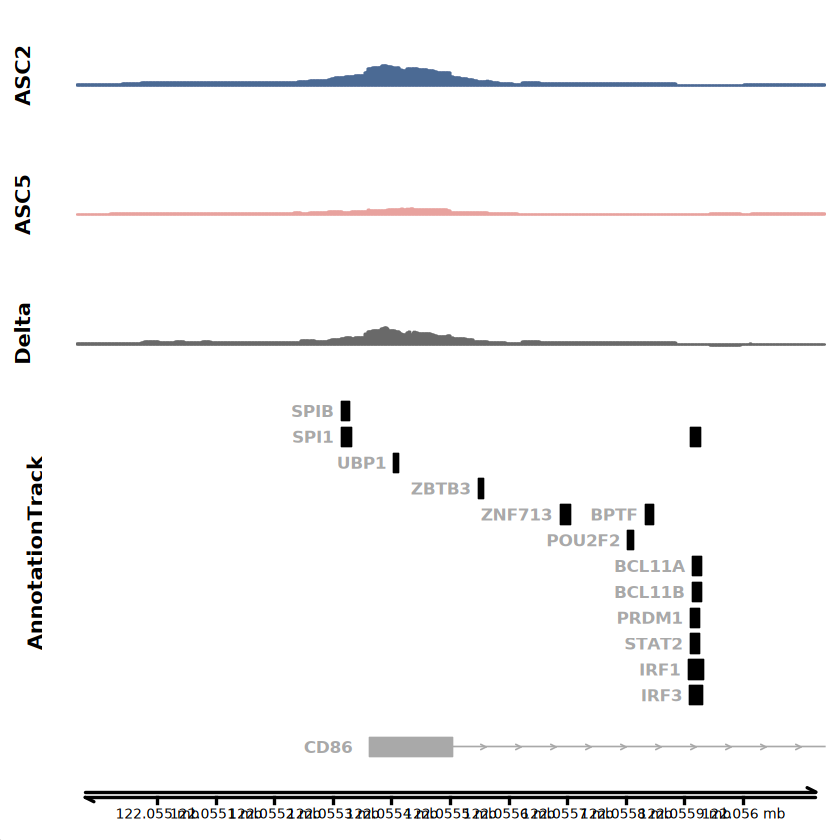

In [303]:
plotTracks(
    list(
        asc2_track,
        asc5_track,
        delta_track,
        motif_track,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 1500,
    to = end - 65000 ,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)

### ITGB7

In [439]:
displayPars(gene_track)$just.group <- "right"
displayPars(motif_track)$just.group <- "right"

In [440]:
gene_track@range <- subset(gene_track@range, gene %in% c(target_region$gene_id))
gene_track@range <- subset(gene_track@range, symbol %in% c('ENST00000549086.2'))
gene_track@range$symbol <- 'ITGB7'

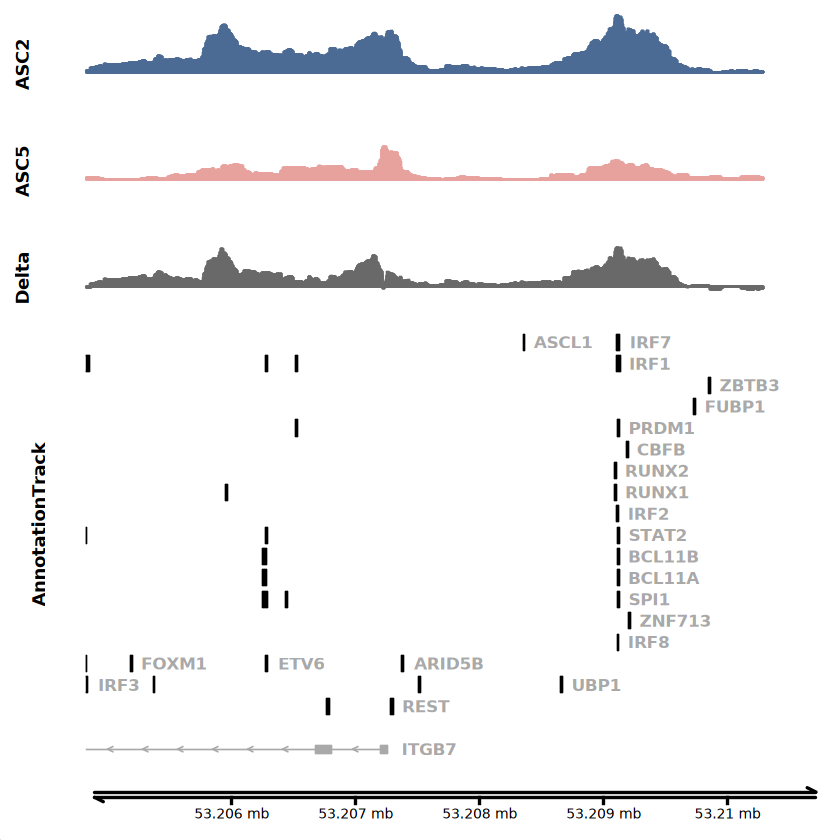

In [441]:
plotTracks(
    list(
        asc2_track,
        asc5_track,
        delta_track,
        motif_track,
        spacer_track,
        gene_track,
        axis_track
    ),
    from = start + 13500,
    to = end + 500,
    chromosome = chr,
    fontcolor.title = 'black',
    fontcolor.legend = 'black',
    background.title = "white"
)